# Whisking state / continuous variable vs LDA-1, for a caller-supplied list of eids

Same analysis as `whisk_state_timepoints.ipynb` (load already-aligned per-bin files ->
warp per trial phase -> correlate with LDA -> trait-persistence checks), but session
selection is a plain list of eids instead of one-session-per-mouse chosen by ordinal
position in each mouse's training history. All eids are treated as a single group (no
per-timepoint faceting/splitting).

Supports both kinds of `variable`:
- **discrete** (`whisk`, `lick`): warped with the **mode** per bin (fraction of time in state).
- **continuous** (`avg_wheel_vel`, `l_paw_x`): abs()-ed, then warped with the **mean** per bin
  (`avg_wheel_vel` is signed around 0; `l_paw_x` is a raw pixel x-coordinate).

Inputs you need to fill in below: `EIDS` (list of eids) and `STATES_PATH` (directory
holding the `{state_file_prefix}{eid}_{mouse_name}` files, with per-bin state +
trial-info columns).

## Parameters

In [80]:
"""
IMPORTS
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

sys.path.append(os.path.abspath(
    os.path.join(os.getcwd(), "..", "segmentation", "1_camera_setup")))

from segmentation_functions import define_trial_types, rescale_sequence

In [98]:
# --- Sessions of interest ------------------------------------------------------
# Every file in STATES_PATH maps to one eid (filename = f"{state_file_prefix}{eid}_{mouse_name}"),
# so eids are discovered directly from that directory's filenames - no separate list needed.
# Leave EIDS empty to use every file found; set it to restrict to a subset of eids.
EIDS = []
GROUP_LABEL = "session_1"          # single group name for the whole eid list

STATES_PATH = "/home/ines/repositories/representation_learning_variability/paper-individuality/data/training/states_files/"+GROUP_LABEL+'/'

prefix = "/home/ines/repositories/"
optimal_k = 4

# LDA table (mouse_name, lda_1 per session)
clustering_path = prefix + 'representation_learning_variability/paper-individuality/clustering/data_files/'
lda_file = "mouse_LDA_5_bins_cut19-08-2026"
exclude_mice = ["PL034"]

# LDA dimensions to analyze (1-based; column d-1 in the LDA file, which has dims 1..23).
lda_dim = 1                       # primary dimension used in the main plots
compare_dims = [1]                # dimensions overlaid in the "flattening" comparison

results_path = prefix + "representation_learning_variability/paper-individuality/learning_individuality/"
os.makedirs(results_path, exist_ok=True)

# --- Column / filename contract for the whisking-state files -----------------
state_file_prefix = '4_states_file_'
# Behavioural variable to analyze. This dataset has no paw/wheel tracking, so
# identifiable_states = "{whisk}{lick}" (2 digits only; digit order matches
# state_columns in 5_syllable_generation for the no-paw/no-wheel case).
#   whisk, lick             -> DISCRETE, binary (0/1) HMM state; already oriented so 1 = active
#   avg_wheel_vel, l_paw_x  -> CONTINUOUS, read directly from the states file (no HMM digit),
#                              then abs()-ed -- avg_wheel_vel is signed around 0 (magnitude
#                              regardless of direction); l_paw_x is a raw pixel x-coordinate
#                              (abs() so left/right excursions don't cancel out).
variable = "lick"              # "whisk" | "lick" | "avg_wheel_vel" | "l_paw_x"
VARIABLE_KIND = {"whisk": "discrete", "lick": "discrete",
                 "avg_wheel_vel": "continuous", "l_paw_x": "continuous"}
IS_DISCRETE = VARIABLE_KIND[variable] == "discrete"
digit_index_map = {"whisk": 0, "lick": 1}
var_digit_index = digit_index_map.get(variable)   # None for continuous variables (unused then)
# States to plot as separate lines. None -> auto: binary vars (whisk/lick) use [1] (active state;
# 0 is its complement). Continuous variables always use a single pseudo-state, "value".
states_override = None

# --- Trial-type / warping parameters ---
trial_type_agg = ["correct_str", "contrast_str", "block_str", "choice"]
target_length = 10          # fixed length each whisking sequence is warped to
# DISCRETE state -> mode per bin; CONTINUOUS value -> mean per bin.
estimator = "mode" if IS_DISCRETE else "mean"
value_label = "fraction of time in state" if IS_DISCRETE else f"mean {variable}"

# --- Correlation / permutation parameters ---
epochs = ["Pre-quiescence", "Quiescence", "Choice", "ITI"]
n_perm = 5000
np.random.seed(0)
dim_col = f"lda_{lda_dim}"

# Tag added to output filenames so runs are traceable
run_tag = variable

## 1. Load LDA

In [99]:
lda = pd.read_pickle(clustering_path + lda_file)
lda = lda.loc[~lda['mouse_name'].isin(exclude_mice)]

dims = sorted(set([lda_dim] + compare_dims))
lda = lda.rename(columns={d - 1: f"lda_{d}" for d in dims})
lda_cols = [f"lda_{d}" for d in dims]
mouse_lda = lda.groupby('mouse_name')[lda_cols].mean().reset_index()   # mean per mouse, per dim

## 2. Discover (eid, mouse_name) pairs from the states directory

Filenames on disk are `{state_file_prefix}{eid}_{mouse_name}`, so we list `STATES_PATH` once and parse each matching filename directly - no separate eid list or eid -> mouse lookup table needed. If `EIDS` is non-empty, results are restricted to that subset.

In [100]:
def discover_states_files(states_path, state_file_prefix, eids=None):
    """One row per states file found in `states_path`. If `eids` is non-empty,
    restrict to files matching those eids and report any that are missing."""
    wanted = set(eids) if eids else None
    rows = []
    for f in sorted(os.listdir(states_path)):
        if not f.startswith(state_file_prefix):
            continue
        rest = f[len(state_file_prefix):]        # "<eid>_<mouse_name>"
        eid, mouse_name = rest[:36], rest[37:]
        if wanted is not None and eid not in wanted:
            continue
        rows.append({"mouse_name": mouse_name, "session": eid, "timepoint": GROUP_LABEL})
    df = pd.DataFrame(rows)
    if wanted is not None:
        missing = sorted(wanted - set(df["session"]))
        if missing:
            print(f"Requested eids with no matching file in {states_path}: {missing}")
    return df


selected = discover_states_files(STATES_PATH, state_file_prefix, EIDS)
if selected.empty:
    raise RuntimeError(
        f"No whisking-state files (prefix '{state_file_prefix}') found in "
        f"{STATES_PATH} - nothing to analyze.")
print(f"Found {len(selected)} sessions across {selected['mouse_name'].nunique()} mice "
      f"in {STATES_PATH}" + (f", matching {len(EIDS)} requested eids." if EIDS else "."))
timepoint_names = [GROUP_LABEL]
selected.head()

Found 47 sessions across 47 mice in /home/ines/repositories/representation_learning_variability/paper-individuality/data/training/states_files/session_1/.


,mouse_name,session,timepoint
0,SWC_058,05382ee9-74df-480a-8fa4-b26cd66eea02,session_1
1,NYU-45,067def0e-cfef-464d-924c-fabd2b38865c,session_1
2,ZFM-01936,0b36f0f9-ce8d-4ef0-96ca-dbafc6948155,session_1
3,DY_014,0f86be49-ca63-4134-8e36-1b29561abaaf,session_1
4,UCLA033,100a92d6-ba17-4168-844e-c81517d59026,session_1


In [102]:
session_1 = [
    "b117ed10-6871-42b3-9193-ca708dac4353",
    "575b16d1-0480-4d00-a4c7-2cd0871e436a",
    "4636ab1e-0522-472b-8eda-69b4223677c7",
    "378cfd07-0ba1-4c01-9807-28585224cd9c",
    "d5d4e946-8d4b-4c35-9073-29966729491c",
    "32599eb4-8331-4fc2-a3d2-6906bdcceea3",
    "e1d9d488-4214-4282-8c8d-5f69db64e864",
    "9400a9eb-62ec-4dc2-b06a-f44eb5d35a12",
    "75e5c60b-462c-4a00-ae04-77baf489bdef",
    "70ec358f-a55b-4b28-9a7a-0a674012930f",
    "f1ee85e7-f863-4648-b32f-9c7b90cc3fdf",
    "a53fed99-d34c-4bf5-a7ec-c0ff7e6350f3",
    "6a6670e3-56a5-4d37-8e07-14262f954f3f",
    "cda5ec4d-f5a3-4cbc-8547-40b57c840d92",
    "8c70e94c-2b22-4eca-8ffc-78578f83a4ff",
    "158e13ee-8eb6-4473-aa3c-1f940b004570",
    "114c0f58-fa7e-4b1c-901b-d201bb9a3b4a",
    "bd6ee800-c2a8-48dc-97e2-456f66b7bb4a",
]

last_session = [
    "03ba8af4-9372-4aa0-9668-ee712affb962",
    "630957dd-23c3-448f-8257-b53deefa10d4",
    "48e62971-e30a-43c6-8dd7-d16d8f4b2c41",
    "9b437eac-791a-481d-bfcd-512a79336fcf",
    "7285c436-37cf-4bd8-b8ea-96139c266ad1",
    "de08cb47-eafc-44a7-b471-8bf3230cac51",
    "76c85772-0dc9-4444-b90c-8cfdcdb37c09",
    "c313de3a-3ae7-40ce-be2e-0b6d7c487fae",
    "63635898-112c-451c-bfd5-4207fffcf74d",
    "a92943b5-c4b5-4d68-8cdb-272a39788ccb",
    "f7c1abec-f074-499b-82da-722ef992607e",
    "04200ab8-ad17-436e-87c0-85115f5cde82",
]

selected = selected.loc[~selected['session'].isin(session_1)]
print(len(selected))

37


## 3. Read the (already-aligned) value per bin

The `5_syllable_generation` files (`{state_file_prefix}{eid}_{mouse}`) are already aligned to
trial phases.
- **DISCRETE** (`whisk`, `lick`): the state is digit `var_digit_index` of `identifiable_states`
  ("{whisk}{lick}", no paw/wheel in this dataset). Binarized one-vs-rest: 1 where the bin is in
  `target_state` (=1), else 0. The mean of this 0/1 signal is the fraction of time in that state.
- **CONTINUOUS** (`avg_wheel_vel`, `l_paw_x`): the raw per-bin value is read directly from the
  states file and abs()-ed (`avg_wheel_vel` is signed around 0 -> magnitude regardless of
  direction; `l_paw_x` is a raw pixel x-coordinate -> abs() so left/right excursions don't
  cancel out). There's no state to binarize against -- the value itself is what gets warped
  and correlated with LDA.

In [103]:
keep_cols = ["Bin", f"{variable}_digit", "broader_label", "trial_id",
             "correct", "choice", "contrast", "block", "wsls",
             "goCueTrigger_times", "mouse_name", "session", "timepoint"]


def load_session_var(mouse_name, session, timepoint):
    """Load an already-aligned states file. For DISCRETE variables, keep the raw state
    DIGIT of `variable` (0..k, NaN where undefined); per-state indicators are formed
    downstream. For CONTINUOUS variables, keep abs() of the raw value (avg_wheel_vel is
    signed around 0 -> magnitude regardless of direction; l_paw_x is a raw pixel
    x-coordinate -> abs() so left/right excursions don't cancel out)."""
    f = os.path.join(STATES_PATH, f"{state_file_prefix}{session}_{mouse_name}")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing state file: {f}")
    df = pd.read_parquet(f)
    if IS_DISCRETE:
        df[f"{variable}_digit"] = pd.to_numeric(
            df["identifiable_states"].astype("string").str[var_digit_index], errors="coerce")
    else:
        df[f"{variable}_digit"] = pd.to_numeric(df[variable], errors="coerce").abs()
    df["mouse_name"] = mouse_name
    df["session"] = session
    df["timepoint"] = timepoint
    return df[[c for c in keep_cols if c in df.columns]]


combined = []
for _, r in selected.iterrows():
    try:
        combined.append(load_session_var(r["mouse_name"], r["session"], r["timepoint"]))
    except Exception as e:
        print(f"  skip  {r['mouse_name']}  {r['session'][:8]}: {type(e).__name__}: {e}")
if not combined:
    raise RuntimeError("No usable sessions after loading state files.")
tp_states = pd.concat(combined, ignore_index=True)
states_out = os.path.join(results_path, f"{run_tag}_states_{GROUP_LABEL}")
tp_states.to_parquet(states_out, compression="gzip")
print(f"{GROUP_LABEL}: {tp_states['session'].nunique()} sessions -> {states_out}")

# --- which states to analyze (one plotted line each) ---
digcol = f"{variable}_digit"
if IS_DISCRETE:
    _present = sorted({int(v) for v in tp_states[digcol].dropna().unique()})
    if states_override is not None:
        STATES = list(states_override)
    elif set(_present) <= {0, 1}:
        STATES = [1]                     # binary -> active state only
    else:
        STATES = _present                # multi-state -> one line per state
else:
    _present = None
    STATES = ["value"]                   # continuous -> single pseudo-state (the value itself)
state_palette = dict(zip(STATES, sns.color_palette("Set2", max(len(STATES), 3))))
print(f"{variable}: states present={_present} -> analyzing STATES={STATES}")

session_1: 37 sessions -> /home/ines/repositories/representation_learning_variability/paper-individuality/learning_individuality/lick_states_session_1
lick: states present=[0, 1] -> analyzing STATES=[1]


### Sanity check: variable value per trial phase

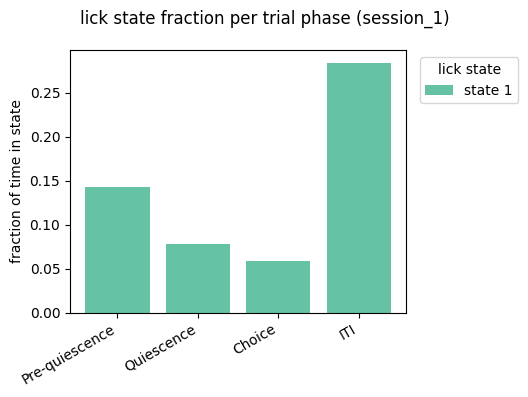

In [104]:
phase_order = ["Pre-quiescence", "Quiescence", "Choice", "ITI"]
allst = tp_states.dropna(subset=["broader_label", digcol])
phases = [p for p in phase_order if p in allst["broader_label"].unique()]

fig, ax = plt.subplots(figsize=(3.4 + 2, 4))
x = np.arange(len(phases))
w = 0.8 / max(len(STATES), 1)
for si, s in enumerate(STATES):
    if IS_DISCRETE:
        vals = [(allst.loc[allst["broader_label"] == p, digcol] == s).mean() for p in phases]
        lbl = f"state {s}"
    else:
        vals = [allst.loc[allst["broader_label"] == p, digcol].mean() for p in phases]
        lbl = variable
    ax.bar(x + si * w, vals, w, label=lbl, color=state_palette[s])
ax.set_xticks(x + w * (len(STATES) - 1) / 2); ax.set_xticklabels(phases, rotation=30, ha="right")
ax.set_ylabel(value_label)
ax.legend(title=(f"{variable} state" if IS_DISCRETE else variable), bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle(f"{variable} {'state fraction' if IS_DISCRETE else 'mean value'} per trial phase ({GROUP_LABEL})")
plt.tight_layout(); plt.show()

## 4. Warp sequences per trial type (mode for discrete states, mean for continuous values)

In [105]:
group_vars = ["sample", "trial_type", "broader_label", "mouse_name"]
seq_col = "seq"


def bin_state_sequences(states_df, state, trial_type_agg, target_length, estimator):
    """DISCRETE: binarize the digit to one state (== state), then mode-warp per trial phase.
    CONTINUOUS: use the (already abs()-ed) value directly, then mean-warp per trial phase."""
    d = states_df.copy()
    if IS_DISCRETE:
        d["_ind"] = np.where(d[digcol].isna(), np.nan, (d[digcol] == state).astype(float))
    else:
        d["_ind"] = d[digcol].astype(float)
    d = define_trial_types(d, trial_type_agg).dropna(subset=["_ind"])
    grouped = (d.groupby(group_vars)["_ind"].apply(list).reset_index()
               .rename(columns={"_ind": "seq_raw"}))
    grouped[seq_col] = grouped["seq_raw"].apply(
        lambda s: rescale_sequence(s, target_length, estimator))
    return grouped


seqs_by_state = {}
for s in STATES:
    seqs = bin_state_sequences(tp_states, s, trial_type_agg, target_length, estimator)
    seq_out = os.path.join(results_path, f"{run_tag}_seq_s{s}_{GROUP_LABEL}")
    seqs.to_parquet(seq_out)
    seqs_by_state[s] = seqs
print(f"{GROUP_LABEL}: warped {len(STATES)} state(s) {STATES}")

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/1_camera_setup/segmentation_functions.py:1335: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'correct' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  states_trial_type.loc[states_trial_type['correct_str']==1., 'correct_str'] = 'correct'


session_1: warped 1 state(s) [1]


### Sanity check: whisking time-course within each phase

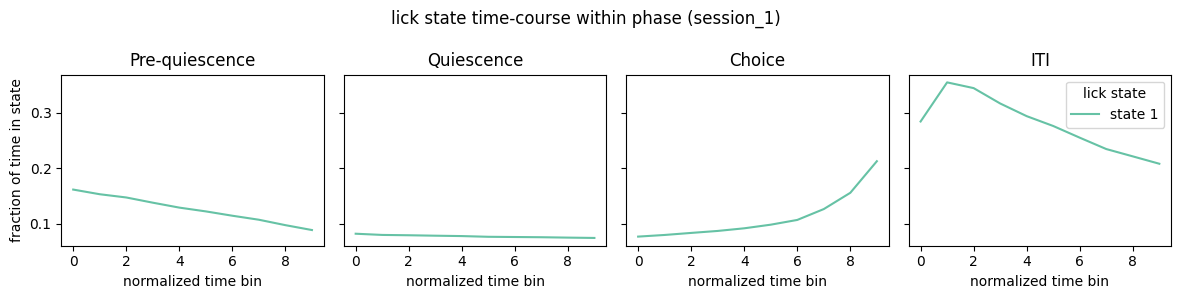

In [106]:
phases = [p for p in phase_order if p in next(iter(seqs_by_state.values()))["broader_label"].unique()]
fig, axs = plt.subplots(1, len(phases), figsize=(3 * len(phases), 3), sharey=True)
axs = np.atleast_1d(axs)
for ax, ph in zip(axs, phases):
    for s, seqs in seqs_by_state.items():
        sub = seqs[seqs["broader_label"] == ph]
        if len(sub) == 0:
            continue
        M = np.vstack([np.asarray(x, dtype=float) for x in sub[seq_col]])
        ax.plot(np.nanmean(M, axis=0), label=(f"state {s}" if IS_DISCRETE else variable), color=state_palette[s])
    ax.set_title(ph); ax.set_xlabel("normalized time bin")
axs[0].set_ylabel(value_label)
axs[-1].legend(title=(f"{variable} state" if IS_DISCRETE else variable))
fig.suptitle(f"{variable} {'state' if IS_DISCRETE else 'value'} time-course within phase ({GROUP_LABEL})")
plt.tight_layout(); plt.show()

## 5. Whisking vs LDA 1

In [107]:
def timepoint_whisk_matrix(sequences, seq_col, epochs):
    s = sequences.copy(); s["session"] = s["sample"].str[:36]
    design = (s.pivot(index=["sample", "trial_type", "mouse_name", "session"],
                      columns="broader_label", values=seq_col).reset_index())
    design = design.dropna(subset=epochs)
    mat = np.vstack(design[epochs].apply(
        lambda row: np.hstack([np.asarray(x, dtype=float) for x in row]), axis=1))
    out = pd.DataFrame(mat); out["mouse_name"] = design["mouse_name"].values
    return out


def lda_correlation_per_timestep(mat_df, mouse_lda, dim_col, n_perm=0):
    L = mat_df.shape[1] - 1
    df = mat_df.merge(mouse_lda[["mouse_name", dim_col]], on="mouse_name")
    pm = df.groupby(["mouse_name", dim_col])[list(range(L))].mean().reset_index()
    lda_vals = pm[dim_col].to_numpy(); vals = pm[list(range(L))].to_numpy()
    coeffs = np.array([pearsonr(lda_vals, vals[:, i])[0] for i in range(L)])
    if n_perm:
        perm = np.full((n_perm, L), np.nan); shuf = lda_vals.copy()
        for k in range(n_perm):
            np.random.shuffle(shuf)
            perm[k] = [pearsonr(shuf, vals[:, i])[0] for i in range(L)]
        lo, hi = np.nanpercentile(perm, [2.5, 97.5], axis=0)
        perm_median = np.nanmedian(perm, axis=0)
    else:
        lo = hi = perm_median = np.zeros(L)
    return {"coeffs": coeffs, "lo": lo, "hi": hi, "perm_median": perm_median,
            "L": L, "n_mice": len(pm)}


mats, corr = {}, {}
for s in STATES:
    m = timepoint_whisk_matrix(seqs_by_state[s], seq_col, epochs)
    mats[s] = m
    corr[s] = lda_correlation_per_timestep(m, mouse_lda, dim_col, n_perm)
    print(f"state {s}: {corr[s]['n_mice']} mice, L={corr[s]['L']}")

_L = next(iter(corr.values()))["L"] if corr else target_length
seq_len = _L // len(epochs)
boundaries = [seq_len * k for k in range(1, len(epochs))]
centers = [seq_len * k + seq_len / 2 for k in range(len(epochs))]

state 1: 37 mice, L=40


### Correlation per timestep, per state

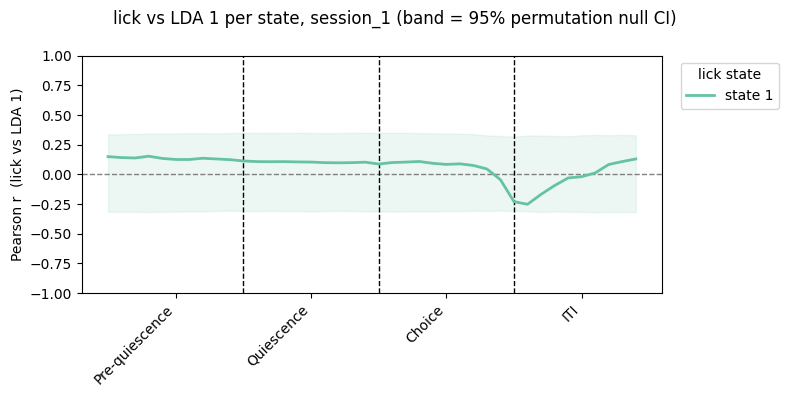

In [108]:
fig, ax = plt.subplots(figsize=(8, 4))
xt = np.arange(_L)
ax.axhline(0, color="grey", ls="--", lw=1)
for b in boundaries: ax.axvline(b, color="k", ls="--", lw=1)
for s in STATES:
    r = corr[s]; c = state_palette[s]
    ax.fill_between(xt, r["lo"], r["hi"], color=c, alpha=0.12)     # 95% null CI per state
    ax.plot(xt, r["coeffs"], color=c, lw=2, label=(f"state {s}" if IS_DISCRETE else variable))
ax.set_ylim([-1, 1])
ax.set_xticks(centers); ax.set_xticklabels(epochs, rotation=45, ha="right")
ax.set_ylabel(f"Pearson r  ({variable} vs LDA {lda_dim})")
ax.legend(title=(f"{variable} state" if IS_DISCRETE else variable), bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle(f"{variable} vs LDA {lda_dim} per state, {GROUP_LABEL} (band = 95% permutation null CI)")
plt.tight_layout(); plt.show()

### Whisking profile by LDA-1 bin

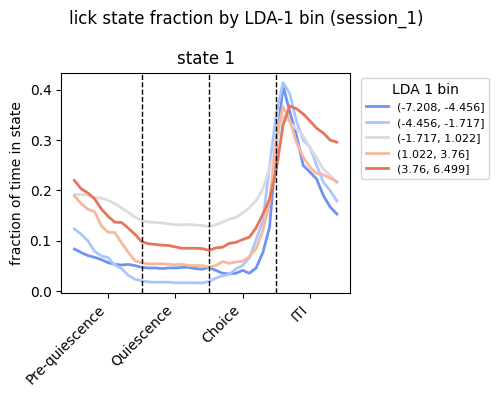

In [109]:
n_bins = 5
bin_col = f"lda_{lda_dim}_bin"
lda_binned = mouse_lda.copy()
lda_binned[bin_col] = pd.cut(lda_binned[dim_col], n_bins)
bin_levels = lda_binned[bin_col].cat.categories
bin_palette = sns.color_palette("coolwarm", n_bins)

fig, axs = plt.subplots(1, len(STATES), figsize=(4.2 * len(STATES) + 1, 4), sharey=True, squeeze=False)
axs = axs[0]
for ax, s in zip(axs, STATES):
    L = corr[s]["L"]
    df = mats[s].merge(lda_binned[["mouse_name", bin_col]], on="mouse_name")
    for bi, level in enumerate(bin_levels):
        subm = df.loc[df[bin_col] == level, list(range(L))]
        if len(subm) == 0: continue
        ax.plot(np.arange(L), subm.to_numpy().mean(axis=0), color=bin_palette[bi], lw=2, label=str(level))
    for b in boundaries: ax.axvline(b, color="k", ls="--", lw=1)
    ax.set_title(f"state {s}" if IS_DISCRETE else variable); ax.set_xticks(centers); ax.set_xticklabels(epochs, rotation=45, ha="right")
axs[0].set_ylabel(value_label)
axs[-1].legend(title=f"LDA {lda_dim} bin", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.suptitle(f"{variable} {'state fraction' if IS_DISCRETE else 'value'} by LDA-{lda_dim} bin ({GROUP_LABEL})")
plt.tight_layout(); plt.show()

### Correlation across LDA dimensions (flattening)

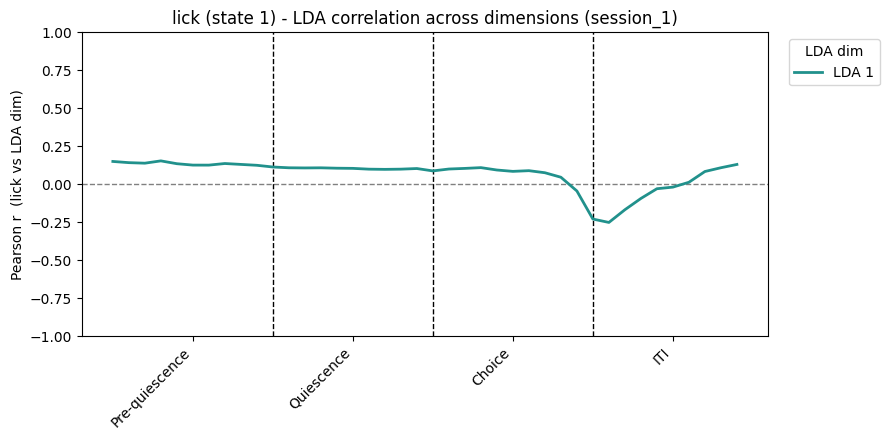

In [110]:
s0 = STATES[0]                    # flattening shown for one state
mat = mats[s0]
dim_palette = sns.color_palette("viridis", len(compare_dims))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axhline(0, color="grey", ls="--", lw=1)
for b in boundaries: ax.axvline(b, color="k", ls="--", lw=1)
for c, d in zip(dim_palette, compare_dims):
    r = lda_correlation_per_timestep(mat, mouse_lda, f"lda_{d}", n_perm=0)
    ax.plot(np.arange(r["L"]), r["coeffs"], color=c, lw=2, label=f"LDA {d}")
ax.set_ylim([-1, 1]); ax.set_xticks(centers); ax.set_xticklabels(epochs, rotation=45, ha="right")
ax.set_ylabel(f"Pearson r  ({variable} vs LDA dim)")
ax.set_title(f"{variable}" + (f" (state {s0})" if IS_DISCRETE else "") + f" - LDA correlation across dimensions ({GROUP_LABEL})")
ax.legend(title="LDA dim", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

## 6. Trait persistence: is this eid list's profile a (scaled) version of proficiency?

In [ ]:
proficiency_profile_file = clustering_path + f"lda_corr_profile_component{lda_dim - 1}_20-07-2026"
prof = pd.read_parquet(proficiency_profile_file)

def prof_col(variable, state):
    """Profile column for this (variable, state). whisk/lick/avg_wheel_vel/l_paw_x are single
    traits (binary state or continuous value); multi-state variables expect a per-state column
    named f'{variable}_{state}'."""
    return variable if variable in ("whisk", "lick", "avg_wheel_vel", "l_paw_x") else f"{variable}_{state}"


Lbins = next(iter(corr.values()))["L"]
r_prof_by_state = {}
for s in STATES:
    col = prof_col(variable, s)
    if col in prof.columns and len(prof[col]) == Lbins:
        r_prof_by_state[s] = prof[col].to_numpy()
    else:
        why = "missing column" if col not in prof.columns else f"len {len(prof.get(col, []))}!={Lbins}"
        print(f"  no proficiency profile for {variable} state {s} (col '{col}': {why}) -> skipped")
print(f"proficiency profiles available for states: {sorted(r_prof_by_state)}")

proficiency profiles available for states: [1]


In [112]:
def _per_mouse(mat_df, mouse_lda, dim_col):
    L = mat_df.shape[1] - 1
    df = mat_df.merge(mouse_lda[["mouse_name", dim_col]], on="mouse_name")
    pm = df.groupby(["mouse_name", dim_col])[list(range(L))].mean().reset_index()
    return pm[dim_col].to_numpy(float), pm[list(range(L))].to_numpy(float)


def trait_persistence(early_mat, r_prof, mouse_lda, dim_col, bins=None, n_perm=5000, seed=0):
    """Projection test + regression slope vs a shuffle-LDA-across-mice null.
    bins=None -> whole trial; pass an index array to restrict to one epoch."""
    rng = np.random.default_rng(seed)
    lda_vals, Y = _per_mouse(early_mat, mouse_lda, dim_col)
    Z = (Y - Y.mean(0)) / (Y.std(0) + 1e-12)
    bins = np.arange(Y.shape[1]) if bins is None else np.asarray(bins)
    rp = np.asarray(r_prof, float)[bins]
    w = rp / (np.linalg.norm(rp) + 1e-12)
    score = Z[:, bins] @ w
    r_proj = pearsonr(score, lda_vals)[0]
    r_early = np.array([pearsonr(lda_vals, Y[:, b])[0] for b in bins])
    fin = np.isfinite(rp) & np.isfinite(r_early)
    slope, intercept = np.polyfit(rp[fin], r_early[fin], 1) if fin.sum() >= 2 else (np.nan, np.nan)
    r_shape = pearsonr(rp[fin], r_early[fin])[0] if fin.sum() >= 2 else np.nan
    npj = np.empty(n_perm); nsl = np.empty(n_perm)
    for k in range(n_perm):
        p = rng.permutation(lda_vals)
        npj[k] = pearsonr(score, p)[0]
        re = np.array([pearsonr(p, Y[:, b])[0] for b in bins])
        nsl[k] = np.polyfit(rp[fin], re[fin], 1)[0] if fin.sum() >= 2 else np.nan
    return dict(r_proj=r_proj, p_proj=(1 + np.sum(npj >= r_proj)) / (n_perm + 1),
                slope=slope, intercept=intercept,
                p_slope=(1 + np.nansum(nsl >= slope)) / (n_perm + 1),
                r_shape=r_shape, r_early=r_early, score=score, lda=lda_vals, n=len(lda_vals))


res_by_state = {}
for s in STATES:
    if s in r_prof_by_state and s in mats:
        res_by_state[s] = trait_persistence(mats[s], r_prof_by_state[s], mouse_lda, dim_col, n_perm=n_perm)
summary = pd.DataFrame([{"state": s, "n": r["n"], "r_proj": r["r_proj"], "p_proj": r["p_proj"],
                         "slope": r["slope"], "p_slope": r["p_slope"], "profile_r": r["r_shape"]}
                        for s, r in res_by_state.items()])
print(f"Trait persistence per state ({variable}, LDA {lda_dim}, {GROUP_LABEL}):")
print(summary.to_string(index=False) if len(summary) else "  (no states with a proficiency profile)")

Trait persistence per state (lick, LDA 1, session_1):
 state  n   r_proj   p_proj     slope  p_slope  profile_r
     1 37 0.067989 0.308938 -0.065715 0.654469   -0.09304


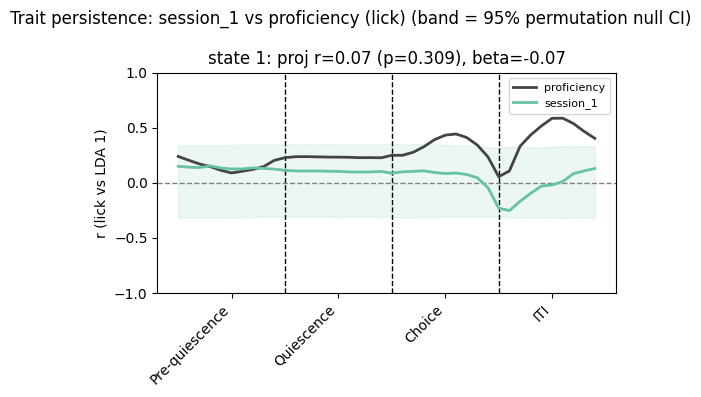

In [113]:
sts = list(res_by_state)
if sts:
    fig, axs = plt.subplots(1, len(sts), figsize=(4.6 * len(sts) + 1, 4), sharey=True, squeeze=False)
    axs = axs[0]
    for ax, s in zip(axs, sts):
        r = res_by_state[s]; rp = r_prof_by_state[s]
        ax.axhline(0, color="grey", ls="--", lw=1)
        for b in boundaries: ax.axvline(b, color="k", ls="--", lw=1)
        ax.fill_between(np.arange(len(r["r_early"])), corr[s]["lo"], corr[s]["hi"],
                        color=state_palette[s], alpha=0.12)     # 95% permutation null CI
        ax.plot(np.arange(len(rp)), rp, color="#444444", lw=2, label="proficiency")
        ax.plot(np.arange(len(r["r_early"])), r["r_early"], color=state_palette[s], lw=2, label=GROUP_LABEL)
        ax.set_ylim([-1, 1]); ax.set_xticks(centers); ax.set_xticklabels(epochs, rotation=45, ha="right")
        ax.set_title(f"state {s}: proj r={r['r_proj']:.2f} (p={r['p_proj']:.3f}), beta={r['slope']:.2f}")
    axs[0].set_ylabel(f"r ({variable} vs LDA {lda_dim})"); axs[0].legend(fontsize=8)
    fig.suptitle(f"Trait persistence: {GROUP_LABEL} vs proficiency ({variable}) (band = 95% permutation null CI)")
    plt.tight_layout(); plt.show()
else:
    print("No states with a proficiency profile - nothing to plot.")

### 6b. Trait persistence per trial epoch x state

Whole-profile projection restricted to each epoch's bins, per state. p-values are
**FDR-BH corrected across the whole state x epoch grid**.

 state          epoch    r_proj   p_proj    slope  p_proj_fdr
     1 Pre-quiescence  0.139168 0.191962 0.093737    0.354596
     1     Quiescence  0.104489 0.229954 0.465311    0.354596
     1         Choice  0.079382 0.265947 0.175650    0.354596
     1            ITI -0.002045 0.504299 0.558301    0.504299


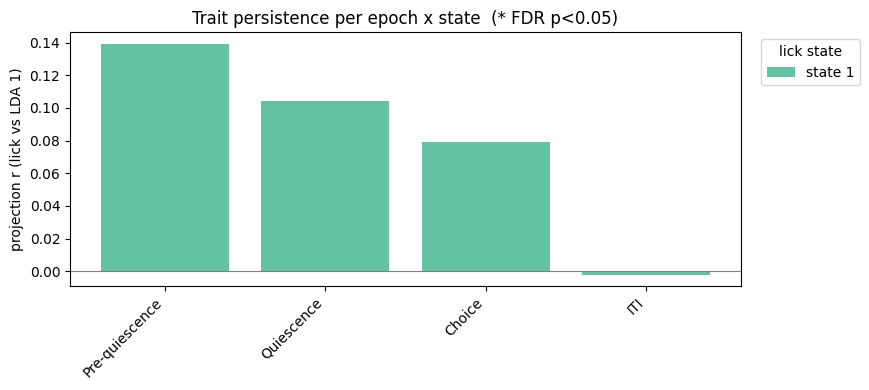

In [114]:
seq_len = next(iter(corr.values()))["L"] // len(epochs)
rows = []
for s in res_by_state:
    for e, ep in enumerate(epochs):
        bidx = np.arange(e * seq_len, (e + 1) * seq_len)
        r = trait_persistence(mats[s], r_prof_by_state[s], mouse_lda, dim_col, bins=bidx, n_perm=n_perm)
        rows.append({"state": s, "epoch": ep, "r_proj": r["r_proj"], "p_proj": r["p_proj"], "slope": r["slope"]})
by = pd.DataFrame(rows)
if len(by):
    by["p_proj_fdr"] = multipletests(by["p_proj"], method="fdr_bh")[1]   # across all state x epoch
    print(by.to_string(index=False))
    fig, ax = plt.subplots(figsize=(1.7 * len(epochs) + 2, 4))
    x = np.arange(len(epochs)); w = 0.8 / max(len(res_by_state), 1)
    for si, s in enumerate(res_by_state):
        sub = by[by["state"] == s].set_index("epoch").reindex(epochs)
        ax.bar(x + si * w, sub["r_proj"], w, color=state_palette[s], label=f"state {s}")
        for xi, (_, row) in enumerate(sub.iterrows()):
            if pd.notna(row["p_proj_fdr"]) and row["p_proj_fdr"] < 0.05:
                ax.text(x[xi] + si * w, row["r_proj"], "*", ha="center",
                        va="bottom" if row["r_proj"] >= 0 else "top", color="crimson", fontsize=13)
    ax.axhline(0, color="grey", lw=.8)
    ax.set_xticks(x + w * (len(res_by_state) - 1) / 2); ax.set_xticklabels(epochs, rotation=45, ha="right")
    ax.set_ylabel(f"projection r ({variable} vs LDA {lda_dim})")
    ax.set_title("Trait persistence per epoch x state  (* FDR p<0.05)")
    ax.legend(title=f"{variable} state", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout(); plt.show()
else:
    print("No states with a proficiency profile.")

## 7. Per-bin early-vs-proficient alignment, per state (FDR across bins)

Per state and per trial bin: alignment `d_b = r_prof(b) * r_early(b)`, shuffle-LDA null,
one-sided p, **FDR-BH across bins within each state** (states are an additional axis).

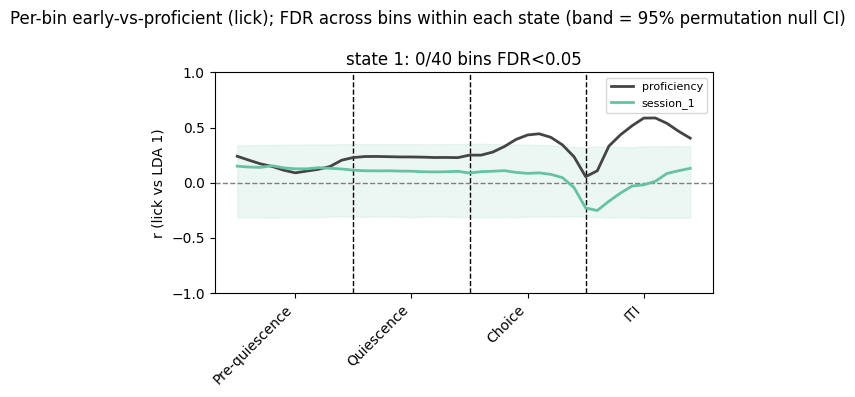

In [115]:
def per_bin_persistence(early_mat, r_prof, mouse_lda, dim_col, n_perm=5000, seed=0):
    rng = np.random.default_rng(seed)
    lda_vals, Y = _per_mouse(early_mat, mouse_lda, dim_col)
    L = Y.shape[1]; rp = np.asarray(r_prof, float)
    r_early = np.array([pearsonr(lda_vals, Y[:, b])[0] for b in range(L)])
    d = rp * r_early
    null = np.empty((n_perm, L))
    for k in range(n_perm):
        p = rng.permutation(lda_vals)
        null[k] = rp * np.array([pearsonr(p, Y[:, b])[0] for b in range(L)])
    ge = np.sum(null >= d[None, :], axis=0)
    p_bin = np.full(L, np.nan); fin = np.isfinite(d)
    p_bin[fin] = (1 + ge[fin]) / (n_perm + 1)
    p_fdr = np.full(L, np.nan); p_fdr[fin] = multipletests(p_bin[fin], method="fdr_bh")[1]
    return dict(r_early=r_early, d=d, p_bin=p_bin, p_fdr=p_fdr, L=L, n=len(lda_vals))


sts = list(res_by_state)
if sts:
    fig, axs = plt.subplots(1, len(sts), figsize=(5 * len(sts) + 1, 4), sharey=True, squeeze=False)
    axs = axs[0]
    for ax, s in zip(axs, sts):
        pb = per_bin_persistence(mats[s], r_prof_by_state[s], mouse_lda, dim_col, n_perm=n_perm)
        sig = pb["p_fdr"] < 0.05; xb = np.arange(pb["L"])
        ax.axhline(0, color="grey", ls="--", lw=1)
        for b in boundaries: ax.axvline(b, color="k", ls="--", lw=1)
        for b in np.where(sig)[0]: ax.axvspan(b - 0.5, b + 0.5, color="crimson", alpha=0.12)
        ax.fill_between(xb, corr[s]["lo"], corr[s]["hi"],
                        color=state_palette[s], alpha=0.12)     # 95% permutation null CI
        ax.plot(xb, r_prof_by_state[s], color="#444444", lw=2, label="proficiency")
        ax.plot(xb, pb["r_early"], color=state_palette[s], lw=2, label=GROUP_LABEL)
        ax.set_ylim([-1, 1]); ax.set_xticks(centers); ax.set_xticklabels(epochs, rotation=45, ha="right")
        ax.set_title(f"state {s}: {int(np.nansum(sig))}/{pb['L']} bins FDR<0.05")
    axs[0].set_ylabel(f"r ({variable} vs LDA {lda_dim})"); axs[0].legend(fontsize=8)
    fig.suptitle(f"Per-bin early-vs-proficient ({variable}); FDR across bins within each state (band = 95% permutation null CI)")
    plt.tight_layout(); plt.show()
else:
    print("No states with a proficiency profile - nothing to plot.")